<a href="https://colab.research.google.com/github/Ayo-Agboola/Python_Data_cleaning-_and_wrangling/blob/main/Week_2_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DATA VISUALISATION**

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Cleaned_Preprocessed_Dataset_Week1.csv')

In [39]:
#Column to datetime
df['Learner SignUp DateTime'] = pd.to_datetime(df['Learner SignUp DateTime'])

#Sort and set as index
df = df.sort_values('Learner SignUp DateTime')
df = df.set_index('Learner SignUp DateTime')

**GROWTH_TREND_OVER_TIME**

This shows whether signups are increasing or decreasing overall

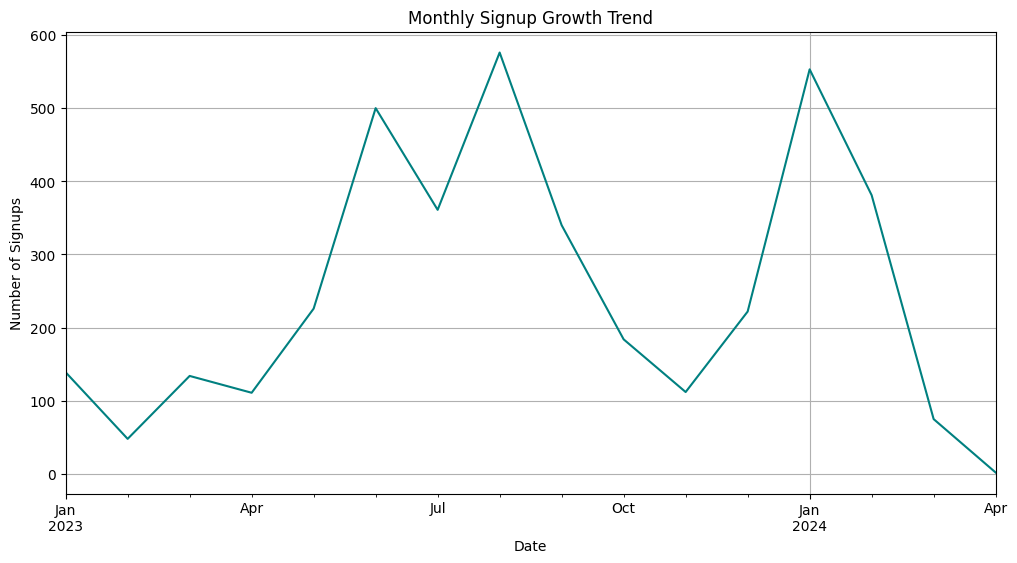

In [22]:
#monthly signup counts
monthly_signups= df.resample('ME').size()

#plot
plt.figure(figsize=(12,6))
monthly_signups.plot(color='teal')
plt.title("Monthly Signup Growth Trend")
plt.xlabel("Date")
plt.ylabel("Number of Signups")
plt.grid(True)
plt.show()

**MONTH_AND_DAY_SEASONALITY**

This identifies the exact high and low engagement periods

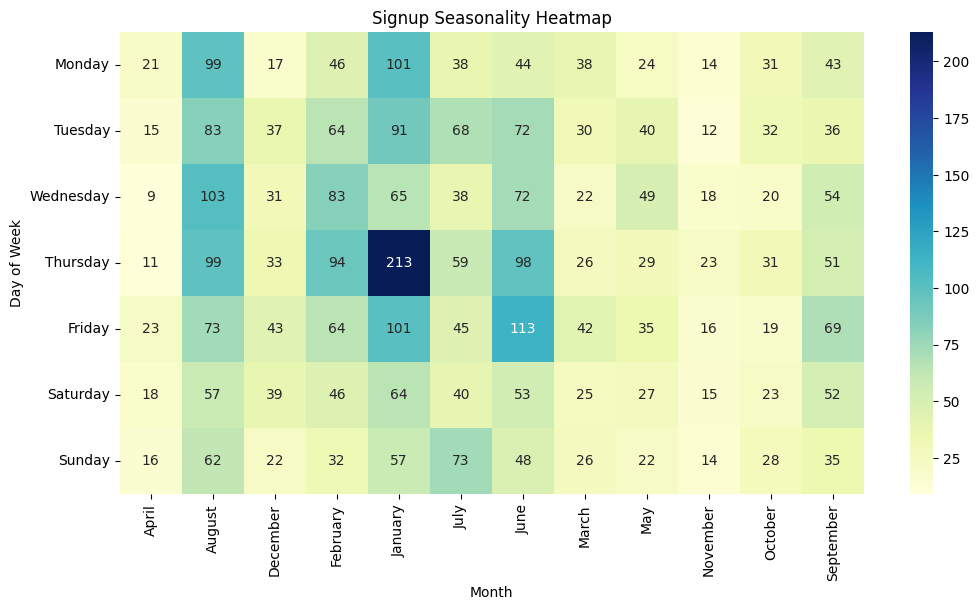

In [53]:

#Month_Name column from index
df['Month_Name'] = df['Learner SignUp DateTime'].dt.month_name()

#Day_of_Week column
df['Day_of_Week'] = df['Learner SignUp DateTime'].dt.day_name()


#Order days
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = df.pivot_table(index='Day_of_Week', columns='Month_Name',
               aggfunc='size',
               fill_value=0)
heatmap_data = heatmap_data.reindex(order)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='d')
plt.title("Signup Seasonality Heatmap")
plt.xlabel("Month")
plt.ylabel("Day of Week")
plt.show()

**SPIKES AND DROPS DETECTION**

This points out abnormal surges or sudden declines and suggest possible causes.

In [71]:
df['Entry created at'] = pd.to_datetime(df['Entry created at'])
df = df.set_index('Entry created at')

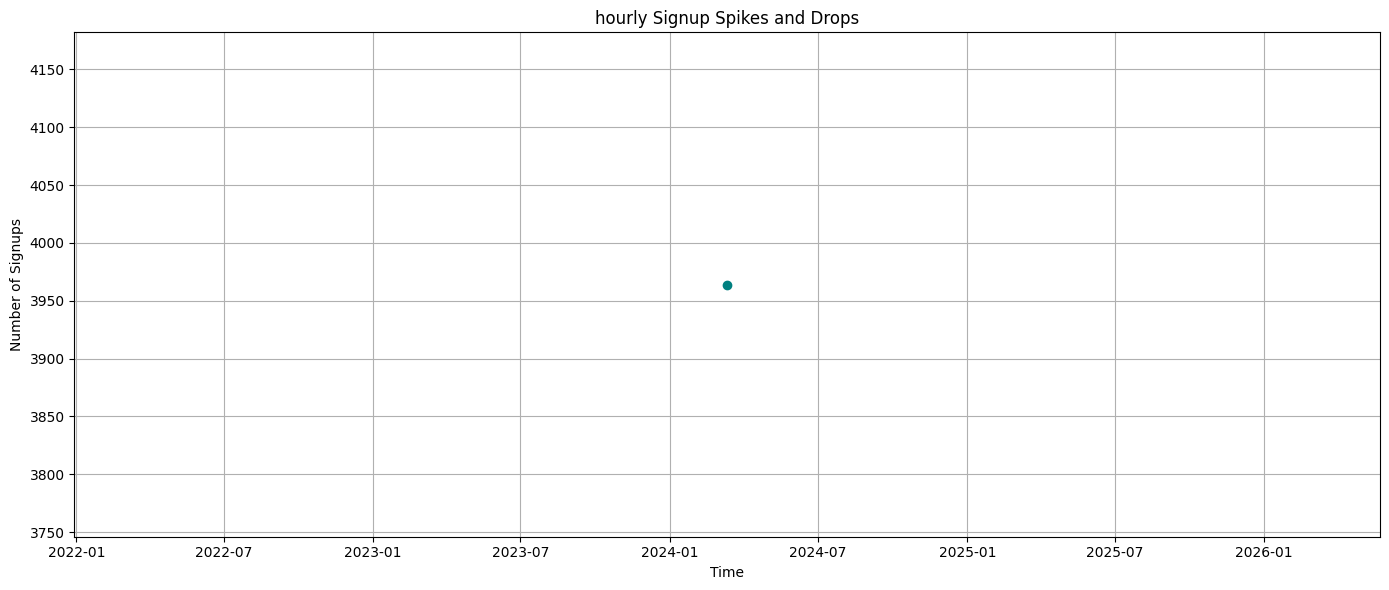

In [83]:
hourly_signups = df.resample('h').size()

plt.figure(figsize=(14,6))
plt.plot(hourly_signups.index,
hourly_signups.values, color='teal', marker='o')
plt.title("hourly Signup Spikes and Drops")
plt.xlabel("Time")
plt.ylabel("Number of Signups")
plt.grid(True)
plt.tight_layout()
plt.show()